# NEOFC - Evaluate replicability of NEOFC estimates across MRI cohorts

In [26]:

from pathlib import Path 
import pandas as pd 
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt 
from tqdm.auto import tqdm
import seaborn as sn
from scipy.stats import spearmanr, pearsonr, combine_pvalues
import statsmodels.formula.api as smf
from pingouin import intraclass_corr
import seaborn.objects as so

from utils import load_neofc_stats, meff_li_ji, sidak, get_ref_data

from nispace.stats.coloc import corr
from nispace.stats.misc import null_to_p

# working directory
wd = Path.cwd() 
print(wd)

# general vars
from utils import (REF_GROUPS, REF_GROUPS_COLORS, REF_GROUPNAMES_PET, REF_NAMES_PET, REF_GROUPS_PET, REF_COLORS_BY_MAP,
                   PARC_DEFAULT, PARCS_ALL, PARCS_CX, 
                   MEASURES_ALL, MEASURES_NICE, MEG_MEASURES_ALL, MEG_FQBANDS, REF_MATH_NAMES)

/Users/llotter/projects/mapfc


## Data

### Mapconn data

In [27]:
parc_cx = "Schaefer200"
parc_wb = "Schaefer200Subcortical"
parcs = [parc_cx, parc_wb]

#### Group stats

In [28]:
neofc_groupstats = {
    "HCP-YA": (
        load_neofc_stats("hcp_ya_mri", parcs, dset="pet", level="group", stats="auc")
        .loc[parcs, "pearson", "all", [1,2]]
        .groupby(["parc", "metric", "variable"])
        .mean()
    ),
    "HCP-EP (controls)": (
        load_neofc_stats("hcp_ep", parcs, index_special="dx", level="group", stats="auc")
        .loc[parcs, "pearson", "all", "CTRL"]
        .droplevel(["measure", "connections", "stat", "dx"])
    ),
    "YRSP": (
        load_neofc_stats("yrsp", parcs, index_special="run", level="group", stats="auc")
        .loc[parcs, "pearson", "all", [1,2]]
        .groupby(["parc", "metric", "variable"])
        .mean()
    ),
    "Ketamine (placebo)": (
        load_neofc_stats("drug_ket", parcs, index_special="treat", level="group", stats="auc")
        .loc[parcs, "pearson", "all", "('placebo', 'pre')"]
        .droplevel(["measure", "connections", "stat", "treat"])
    ),
    "Risperidone (placebo)": (
        load_neofc_stats("drug_risp", parcs, index_special="treat", level="group", stats="auc")
        .loc[parcs, "pearson", "all", "placebo"]
        .droplevel(["measure", "connections", "stat", "treat"])
    ),
    "MPH (placebo)": (
        load_neofc_stats("drug_mph", parc_cx, index_special="treat", level="group", stats="auc")
        .loc[[parc_cx], "pearson", "all", "placebo"]
        .droplevel(["measure", "connections", "stat", "treat"])
    ),
    "HCP-YA (MEG-beta)": (
        load_neofc_stats("hcp_ya_meg", parc_cx, index_special="fqband", level="group", stats="auc")
        .loc[[parc_cx], "aec", "all", "beta"]
        .droplevel(["measure", "connections", "stat", "fqband"])
    ),
}
neofc_groupstats = pd.concat(neofc_groupstats, axis=0, names=["dset", "parc", "metric", "variable"])
neofc_groupstats

Loading group stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ya_mri/parc-..._dset-pet_stat-..._group.csv.gz
Loading group stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ep/parc-..._stat-..._group.csv.gz
Loading group stats: /Users/llotter/projects/mapfc/results/neofc/yrsp/parc-..._stat-..._group.csv.gz
Loading group stats: /Users/llotter/projects/mapfc/results/neofc/drug_ket/parc-..._stat-..._group.csv.gz
Loading group stats: /Users/llotter/projects/mapfc/results/neofc/drug_risp/parc-..._stat-..._group.csv.gz
Loading group stats: /Users/llotter/projects/mapfc/results/neofc/drug_mph/parc-..._stat-..._group.csv.gz
Loading group stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ya_meg/parc-..._stat-..._group.csv.gz


5HT1a     5HT1b     5HT2a  \
dset              parc        metric   variable                                 
HCP-YA            Schaefer200 delta    max       0.000674  0.024287 -0.002330   
                                       mean     -0.043202 -0.006599 -0.050035   
                                       mean_rz  -1.683278  0.018822 -2.136860   
                                       mean_z   -1.793425  0.105759 -2.044856   
                                       min      -0.086944 -0.046027 -0.119867   
...                                                   ...       ...       ...   
HCP-YA (MEG-beta) Schaefer200 inverted min       0.010431  0.008176  0.008788   
                                       max       0.039274  0.035121  0.029488   
                                       p         0.391000  0.275000  0.035000   
                                       pz        0.428132  0.256850  0.021893   
                                       pmeff     0.986468  0.938579  0.265889   

                                                     5HT4      5HT6      5HTT  \
dset              parc        metric   variable                                 
HCP-YA            Schaefer200 delta    max      -0.008286 -0.007789  0.048543   
                                       mean     -0.051383 -0.048874  0.002754   
                                       mean_rz  -2.140254 -1.997437  0.005032   
                                       mean_z   -2.123255 -1.902144  0.002997   
                                       min      -0.110309 -0.106316 -0.034365   
...                                                   ...       ...       ...   
HCP-YA (MEG-beta) Schaefer200 inverted min       0.009119  0.010942  0.007781   
                                       max       0.030830  0.035305  0.027325   
                                       p         0.323000  0.056000  0.358000   
                                       pz        0.329202  0.040758  0.416598   
                                       pmeff     0.966099  0.393457  0.978610   

                                                     A4B2       CB1    CMRglu  \
dset              parc        metric   variable                                 
HCP-YA            Schaefer200 delta    max       0.034240 -0.006161  0.021511   
                                       mean     -0.005157 -0.055679 -0.002442   
                                       mean_rz  -0.283035 -2.496793 -0.023199   
                                       mean_z   -0.348312 -2.494819 -0.019419   
                                       min      -0.038663 -0.108849 -0.031134   
...                                                   ...       ...       ...   
HCP-YA (MEG-beta) Schaefer200 inverted min      -0.005067  0.006948 -0.003729   
                                       max       0.009843  0.029362  0.005899   
                                       p         0.901000  0.217000  0.902000   
                                       pz        0.885283  0.231099  0.897814   
                                       pmeff     1.000000  0.880244  1.000000   

                                                       D1  ...      HDAC  \
dset              parc        metric   variable            ...             
HCP-YA            Schaefer200 delta    max      -0.010543  ...  0.016951   
                                       mean     -0.046439  ... -0.006834   
                                       mean_rz  -1.582581  ... -0.008945   
                                       mean_z   -1.639719  ... -0.033673   
                                       min      -0.090413  ... -0.031960   
...                                                   ...  ...       ...   
HCP-YA (MEG-beta) Schaefer200 inverted min       0.005797  ...  0.000983   
                                       max       0.033675  ...  0.016963   
                                       p         0.155000  ...  0.327000   
                                       pz        0.155

#### Individual stats

In [29]:
neofc_indivstats = {
    "HCP-YA": (
        load_neofc_stats("hcp_ya_mri", parcs, dset="pet", level="individual", stats="auc")
        .loc[parcs, "pearson", "all", [1,2]]
        .groupby(["parc", "metric", "variable", "id"])
        .mean()
    ),
    "HCP-EP (controls)": (
        load_neofc_stats("hcp_ep", parcs, index_special="dx", level="individual", stats="auc")
        .loc[parcs, "pearson", "all", "CTRL"]
        .droplevel(["measure", "connections", "stat", "dx"])
    ),
    "YRSP": (
        load_neofc_stats("yrsp", parcs, index_special="run", level="individual", stats="auc")
        .loc[parcs, "pearson", "all", [1,2]]
        .groupby(["parc", "metric", "variable", "id"])
        .mean()
    ),
    "Ketamine (placebo)": (
        load_neofc_stats("drug_ket", parcs, index_special="treat", level="individual", stats="auc")
        .loc[parcs, "pearson", "all", "('placebo', 'pre')"]
        .droplevel(["measure", "connections", "stat", "treat"])
    ),
    "Risperidone (placebo)": (
        load_neofc_stats("drug_risp", parcs, index_special="treat", level="individual", stats="auc")
        .loc[parcs, "pearson", "all", "placebo"]
        .droplevel(["measure", "connections", "stat", "treat"])
    ),
    "MPH (placebo)": (
        load_neofc_stats("drug_mph", parc_cx, index_special="treat", level="individual", stats="auc")
        .loc[[parc_cx], "pearson", "all", "placebo"]
        .droplevel(["measure", "connections", "stat", "treat"])
    ),
    "HCP-YA (MEG-beta)": (
        load_neofc_stats("hcp_ya_meg", parc_cx, index_special="fqband", level="individual", stats="auc")
        .loc[[parc_cx], "aec", "all", "beta"]
        .droplevel(["measure", "connections", "stat", "fqband"])
    ),
}

# concat
neofc_indivstats = pd.concat(neofc_indivstats, axis=0, names=["dset", "parc", "metric", "variable", "id"])
#neofc_indivstats

Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ya_mri/parc-..._dset-pet_stat-..._individual.csv.gz
Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ep/parc-..._stat-..._individual.csv.gz
Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/yrsp/parc-..._stat-..._individual.csv.gz
Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/drug_ket/parc-..._stat-..._individual.csv.gz
Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/drug_risp/parc-..._stat-..._individual.csv.gz
Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/drug_mph/parc-..._stat-..._individual.csv.gz
Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ya_meg/parc-..._stat-..._individual.csv.gz


## Calculate replicability

### Correlation matrix

In [30]:
val = "val_rz" # use robust z-scores to limit influence of autocorrelation

neofc_mri_replic_corr = {}
for parc in parcs:
    for metric in ["original", "inverted"]:
        neofc_mri_replic_corr[(parc, metric)] = (
            neofc_indivstats
            .loc[(slice(None), parc, metric, val, slice(None)), REF_NAMES_PET]
            .groupby("dset").mean().T.corr("spearman")
            .reset_index(names="cohort2")
            .melt(id_vars="cohort2", var_name="cohort1", value_name="Spearman's rho")
        )

neofc_mri_replic_corr = (
    pd.concat(neofc_mri_replic_corr, axis=0, names=["parc", "metric", "stat"])
    .reset_index().set_index(["parc", "metric", "cohort1", "cohort2"])
    .loc[:, "Spearman's rho"]
)
neofc_mri_replic_corr.to_csv(wd / "results" / "replicability" / "neofc_mri_replic_corr.csv")
neofc_mri_replic_corr

parc                    metric    cohort1            cohort2              
Schaefer200             original  HCP-EP (controls)  HCP-EP (controls)        1.000000
                                                     HCP-YA                   0.918462
                                                     HCP-YA (MEG-beta)        0.585385
                                                     Ketamine (placebo)       0.845385
                                                     MPH (placebo)            0.836154
                                                                                ...   
Schaefer200Subcortical  inverted  YRSP               HCP-EP (controls)        0.983846
                                                     HCP-YA                   0.955385
                                                     Ketamine (placebo)       0.874615
                                                     Risperidone (placebo)    0.945385
                                                     YR

### ICCs

In [31]:
val = "val_rz" # use robust z-scores to limit influence of autocorrelation

def calc_icc(df):
    df_melt = df.reset_index(names="map").melt(id_vars="map", var_name="dset", value_name="auc")
    #display(df_melt)
    icc_result = intraclass_corr(
         data=df_melt, 
         targets="map", 
         raters="dset", 
         ratings="auc"
    )
    return icc_result.loc[2,:]

neofc_mri_replic_icc = {}
for dsets in ["All", "Without MEG"]:
    for parc in parcs:
        for metric in ["original", "inverted"]:
            #print(metric)
            tmp = neofc_indivstats.loc[(slice(None), parc, metric, val, slice(None)), REF_NAMES_PET]
            if dsets == "Without MEG":
                tmp = tmp.loc[~tmp.index.get_level_values("dset").isin(["HCP-YA (MEG)"])]
            tmp = tmp.groupby("dset").mean().T
            neofc_mri_replic_icc[dsets, parc, metric] = calc_icc(tmp)

neofc_mri_replic_icc = pd.concat(neofc_mri_replic_icc, axis=1, names=["datasets", "parc", "metric"]).T
neofc_mri_replic_icc["ICC"] = neofc_mri_replic_icc["ICC"].astype(float).round(2)
neofc_mri_replic_icc["F"] = neofc_mri_replic_icc["F"].astype(float).round(2)
neofc_mri_replic_icc.to_csv(wd / "results" / "replicability" / "neofc_mri_replic_icc.csv")

neofc_mri_replic_icc

Type          Description   ICC  \
datasets    parc                   metric                                      
All         Schaefer200            original  ICC3  Single fixed raters  0.87   
                                   inverted  ICC3  Single fixed raters  0.89   
            Schaefer200Subcortical original  ICC3  Single fixed raters  0.92   
                                   inverted  ICC3  Single fixed raters  0.94   
Without MEG Schaefer200            original  ICC3  Single fixed raters  0.87   
                                   inverted  ICC3  Single fixed raters  0.89   
            Schaefer200Subcortical original  ICC3  Single fixed raters  0.92   
                                   inverted  ICC3  Single fixed raters  0.94   

                                                 F df1  df2 pval         CI95%  
datasets    parc                   metric                                       
All         Schaefer200            original  48.41  24  144  0.0  [0.79, 0.93]  
                                   inverted  59.13  24  144  0.0  [0.82, 0.94]  
            Schaefer200Subcortical original  59.06  24   96  0.0  [0.86, 0.96]  
                                   inverted  73.86  24   96  0.0  [0.89, 0.97]  
Without MEG Schaefer200            original  48.41  24  144  0.0  [0.79, 0.93]  
                                   inverted  59.13  24  144  0.0  [0.82, 0.94]  
            Schaefer200Subcortical original  59.06  24   96  0.0  [0.86, 0.96]  
                                   inverted  73.86  24   96  0.0  [0.89, 0.97]

## Calculate meta p values

In [32]:
val = "val" # use raw values for meta-analysis, we dont need robust z because we are looking at each atlas individually
neofc_mri_metap = {}

# datasets to include
dsets = ["HCP-YA", "HCP-EP (controls)", "YRSP", "Ketamine (placebo)", "Risperidone (placebo)", "MPH (placebo)"]

for parc in parcs:
    weights = neofc_indivstats.loc[dsets, parc, "original", val].groupby("dset").size()
    print(f"parc: {parc}, weights:\n{weights}")
    
    # meff
    meff = meff_li_ji(get_ref_data("pet", parc).T.corr())
    print(f"meff: {meff}")
    
    for metric in ["original", "inverted"]:
        
        for m in REF_NAMES_PET:
            
            # Original p values
            pvals = neofc_groupstats.loc[dsets, parc, metric, "p"][m]
            
            # Stouffer's method (with weights)
            neofc_mri_metap[parc, metric, m] = pd.Series(
                combine_pvalues(pvals, method="stouffer", weights=weights), 
                index=["Z", "p"], dtype=float
            )
            neofc_mri_metap[parc, metric, m]["pmeff"] = sidak(
                neofc_mri_metap[parc, metric, m]["p"], meff)

neofc_mri_metap = pd.concat(neofc_mri_metap, axis=1, names=["parc", "metric", "map"]).T
neofc_mri_metap.to_csv(wd / "results" / "replicability" / "neofc_mri_metap.csv")

neofc_mri_metap.loc["Schaefer200", "original", :, :]

parc: Schaefer200, weights:
dset
HCP-EP (controls)         55
HCP-YA                   112
Ketamine (placebo)        28
MPH (placebo)             30
Risperidone (placebo)     17
YRSP                      26
dtype: int64
Loading parcellated pet data, standardized=True, null=False
meff: 8.67582031582078
parc: Schaefer200Subcortical, weights:
dset
HCP-EP (controls)         55
HCP-YA                   112
Ketamine (placebo)        28
Risperidone (placebo)     17
YRSP                      26
dtype: int64
Loading parcellated pet data, standardized=True, null=False
meff: 8.578752917752306


,Z,p,pmeff
map,,,
CMRglu,1.579265,5.713762e-02,3.997694e-01
SV2A,1.672758,4.718744e-02,3.425350e-01
HDAC,0.710594,2.386681e-01,9.061233e-01
VMAT2,0.753098,2.256955e-01,8.913028e-01
mGluR5,3.110041,9.353066e-04,8.085485e-03
NMDA,-0.150671,5.598824e-01,9.991915e-01
GABAa,0.306039,3.797875e-01,9.841467e-01
GABAa5,-0.369505,6.441244e-01,9.998720e-01
NET,6.077113,6.118273e-10,5.308103e-09


## Plot 

### Bar plots

In [33]:
def plot_auc_reproducibility(save_path=None, val="val_rz"):
    
    # null variables
    null_vars = ["null_1%", "null_10%", "null_25%", "null_50%", "null_75%", "null_90%", "null_99%",
                 "null_mean", "null_std"]
    
    # DATA
    dsets = neofc_indivstats.index.get_level_values("dset").unique()
    dfs = {}
    for dset in dsets:
        for metric in ["original", "inverted"]:
            dfs_per_parc = {}
            for parc in parcs:
                if parc not in neofc_indivstats.loc[dset].index.get_level_values("parc"):
                    continue
                
                # actual data
                df_data = (
                    neofc_indivstats
                    .loc[(dset, parc, metric, val, slice(None)), REF_NAMES_PET]
                    .reset_index(drop=True)
                    .describe([0.1,0.9])
                )
                #display(df_data)

                try:        
                    # null data
                    df_null = (
                        neofc_groupstats
                        .loc[(dset, parc, "original", null_vars), REF_NAMES_PET]
                        .reset_index(drop=True)
                        .assign(variable=null_vars).set_index("variable")
                    )
                    if val=="val_rz":
                        df_null = (df_null - df_null.loc["null_mean"].values) / df_null.loc["null_std"].values
                    df_null = df_null.drop(index=["null_mean", "null_std"])
                    
                    # p
                    df_p = (
                        neofc_groupstats
                        .loc[(dset, parc, metric, ["p", "pmeff"]), REF_NAMES_PET]
                        .reset_index(drop=True)
                        .assign(variable=["p", "pmeff"]).set_index("variable")
                    )
                    # concat
                    dfs_per_parc[parc] = pd.concat([df_data, df_null, df_p], axis=0).T
                except:
                    dfs_per_parc[parc] = df_data.T
                    
            dfs[dset, metric] = pd.concat(dfs_per_parc.values(), axis=0, keys=dfs_per_parc.keys(), names=["parc", "map"])

        #print(metric)
        #display(dfs[dset, metric])
        
    # PLOT   
    bar_alpha = 0.5
    def plot_bars(dset, metric, ax, x_range, title=None, bar_alpha=bar_alpha):
        df = dfs[dset, metric]
        if title is None:
            title = dset.replace(" ", "\n")
        
        # bars
        (
            so.Plot(data=df.reset_index())
            .add(so.Bar(alpha=bar_alpha + 0.2, edgewidth=0), so.Dodge(by=["group"]), 
                 x="mean", y="map", color="map", group="parc", legend=False)
            .add(so.Bar(edgecolor="k", alpha=bar_alpha, edgewidth=1.5), so.Dodge(by=["group"]), 
                 x="mean", y="map", color="parc", group="parc", legend=False)
            .scale(color={parc_cx: "k", parc_wb: "w"} | REF_COLORS_BY_MAP)
            .add(so.Range(color="k"), so.Dodge(by=["group"]), 
                 xmin="10%", xmax="90%", y="map", group="parc", legend=False)
            .label(y="")
            .on(ax)
            .plot()
        )
        
        # nulls
        try:
            df.loc[(parc_cx, REF_NAMES_PET), "y_index"] = np.arange(len(REF_NAMES_PET)) - 0.2
            if parc_wb in df.index.get_level_values("parc"):
                df.loc[(parc_wb, REF_NAMES_PET), "y_index"] = np.arange(len(REF_NAMES_PET)) + 0.2
            df_sorted = df.sort_values("y_index")
            ax.plot(df_sorted["null_50%"], df_sorted["y_index"], lw=1.5, color="0.3", zorder=-1000,
                    label="Null median")            
            for p1, p2, c in [
                ("null_1%", "null_99%", "0.9"), 
                ("null_10%", "null_90%", "0.8"), 
                ("null_25%", "null_75%", "0.7")
            ]:
                ax.fill_betweenx(
                    df_sorted["y_index"], df_sorted[p1], df_sorted[p2], 
                    color=c, 
                    zorder=-1001,
                    alpha=1,
                    label=f"{p2.replace('null_', '')} PI of null means"
                )
                
            # significance
            x_offset = np.diff(ax.get_xlim()) * 0.1    
            for l in ax.get_yticklabels():
                m = l.get_text()
                
                # iterate cortex/whole-brain
                if parc_wb in df.index.get_level_values("parc"):
                    iterate = [(parc_cx, -0.25), (parc_wb, 0.2)]
                else:
                    iterate = [(parc_cx, 0)]
                for parc, y_offset in iterate:
                    
                    p = df.loc[(parc, m), "p"]
                    pmeff = df.loc[(parc, m), "pmeff"]
                    if p < 0.05:
                        if df.loc[(parc, m), "mean"] > 0:
                            x = df.loc[(parc, m), "90%"] + x_offset
                        else:
                            x = df.loc[(parc, m), "10%"] - x_offset
                        y = l.get_position()[1] + y_offset
                        ax.plot(x, y, marker="$★$" if pmeff < 0.05 else "$☆$", markersize=8, 
                                linestyle="None", color=REF_COLORS_BY_MAP[m])
        
        except:
            pass
        
        # layout
        ax.set_title(title)
        ax.set_ylim(len(REF_NAMES_PET), -1)
        if x_range is not None:
            ax.set_xlim(x_range)
        else:
            xmax = df["90%"].abs().max().max() + (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.3
            xmin = -xmax if metric == "delta" else df["10%"].min().min() - (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.1
            ax.set_xlim(xmin, xmax)
        ax.set_xlabel("Z(AUC)" if val == "val_rz" else "AUC")
        if not ax.get_subplotspec().is_first_col():
            ax.set_yticklabels([])
        else:
            for l in ax.get_yticklabels():
                l.set_color(REF_COLORS_BY_MAP[l.get_text()])
            
    
    fig, axes = plt.subplots(2, len(dsets), figsize=(2 * len(dsets), 18), sharey=False, sharex=False)

    for c, dset in enumerate(dsets):
        for r, metric in enumerate(["original", "inverted"]):
            ax = axes[r, c]
            
            plot_bars(dset, metric, ax, None)
            
            if ax.get_subplotspec().is_first_col():
                ax.annotate(f"$AUC{'+' if metric=='original' else '-'}$", xy=(-0.6, 0.5), xycoords="axes fraction", 
                            ha="right", va="center", fontsize=16, rotation=90)
            elif ax.get_subplotspec().is_first_row() and ax.get_subplotspec().is_last_col():
                # legend
                handles, labels = axes[r, c-1].get_legend_handles_labels()
                handle_bar_color = plt.Rectangle((0, 0), 1, 1, color=REF_COLORS_BY_MAP["NET"], ec="k", alpha=bar_alpha + 0.2)
                handle_bar_black = plt.Rectangle((0, 0), 1, 1, color="k", lw=1.5, ec="k", alpha=bar_alpha)
                handle_bar_white = plt.Rectangle((0, 0), 1, 1, color="w", lw=1.5, ec="k", alpha=bar_alpha)
                handle_line = plt.Line2D([0.5, 0], [2, 0], color="k", marker="none")
                cxbar_handle = ((handle_bar_color, handle_bar_black), handle_line)
                wbbar_handle = ((handle_bar_color, handle_bar_white), handle_line)
                star_handle = (plt.Line2D([0], [0], color=REF_COLORS_BY_MAP["NET"], marker="$☆$", markersize=9, linestyle="None"),
                               plt.Line2D([0], [0], color=REF_COLORS_BY_MAP["NET"], marker="$★$", markersize=9, linestyle="None"))
                handles_dict = {
                    f"$\\bf{{Cortex}}$\nMean AUC (90% PI)": cxbar_handle,
                    f"$\\bf{{Whole\ brain}}$\nMean AUC (90% PI)": wbbar_handle,
                    "$p\ /\ p_{Meff} < 0.05$": star_handle, 
                }
                ax.legend(
                    list(handles_dict.values()) + handles, 
                    list(handles_dict.keys()) + labels, 
                    loc="center left", bbox_to_anchor=(1.1, 0.5),
                    handler_map={
                        cxbar_handle: mpl.legend_handler.HandlerTuple(ndivide=None, pad=-0.5),
                        wbbar_handle: mpl.legend_handler.HandlerTuple(ndivide=None, pad=-0.5),
                        star_handle: mpl.legend_handler.HandlerTuple(ndivide=None)
                    }
                )
                
    # save
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=400)


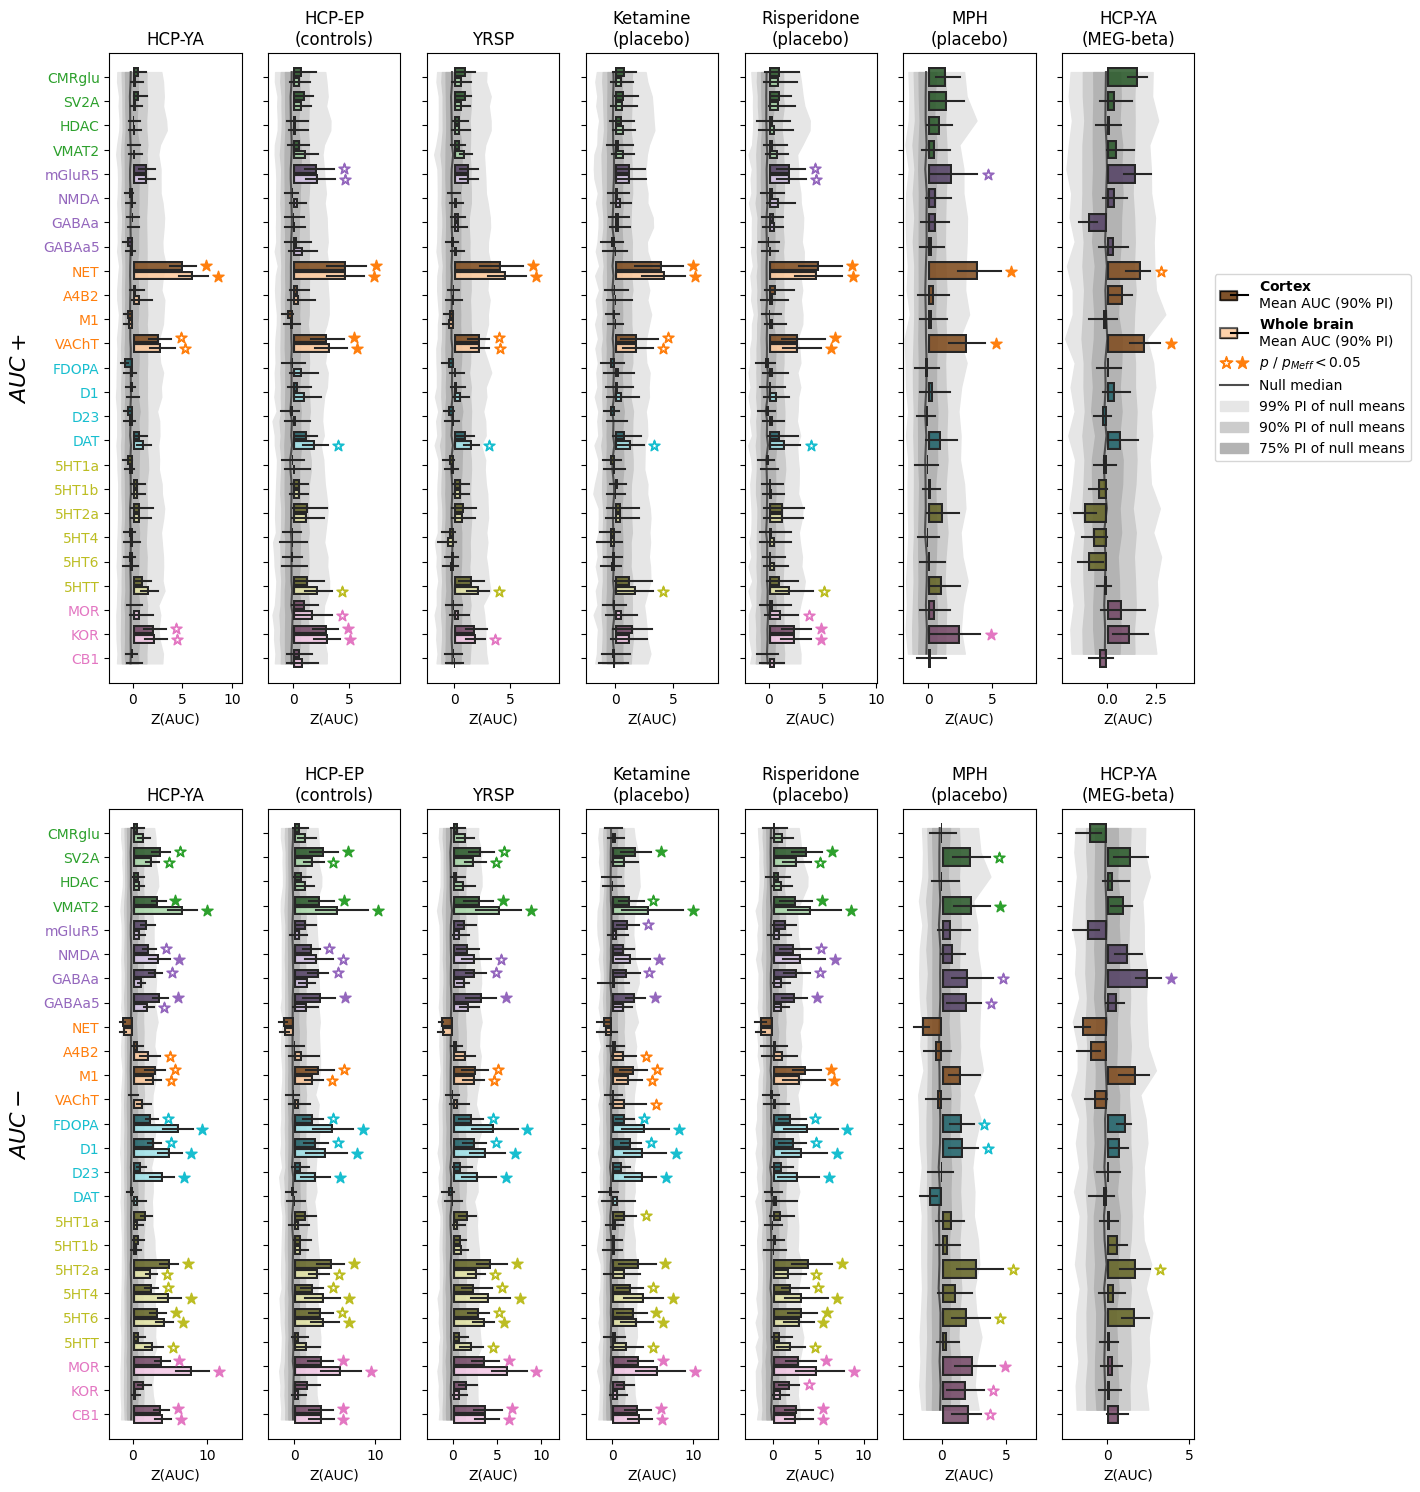

In [34]:
plot_auc_reproducibility(
    save_path=wd / "plots" / "replicability" / f"auc_parc-Schaefer200.pdf",
)

### Meta p values

In [35]:
def plot_metap(save_path=None):
    
    fig, axes = plt.subplots(1, 2, figsize=(3.5, 10), gridspec_kw={"wspace": 0.1}, sharex=True)
    
    bar_alpha = 0.5
    def plot_bars(metric, ax, x_range, title=None, bar_alpha=bar_alpha):
        df = neofc_mri_metap.loc[:, metric, :]
        if title is None:
            title = f"$AUC{'+' if metric=='original' else '-'}$"
        
        # bars
        (
            so.Plot(data=df.reset_index())
            .add(so.Bar(alpha=bar_alpha + 0.2, edgewidth=0), so.Dodge(by=["group"]), 
                 x="Z", y="map", color="map", group="parc", legend=False)
            .add(so.Bar(edgecolor="k", alpha=bar_alpha, edgewidth=1.5), so.Dodge(by=["group"]), 
                 x="Z", y="map", color="parc", group="parc", legend=False)
            .scale(color={parc_cx: "k", parc_wb: "w"} | REF_COLORS_BY_MAP)
            .label(y="")
            .limit(x=x_range)
            .on(ax)
            .plot()
        )
    
        # significance
        x_offset = np.diff(ax.get_xlim()) * 0.07
        for l in ax.get_yticklabels():
            m = l.get_text()
            
            # iterate cortex/whole-brain
            for parc, y_offset in [(parc_cx, -0.25), (parc_wb, 0.2)]:
                
                p = df.loc[(parc, m), "p"]
                pmeff = df.loc[(parc, m), "pmeff"]
                if p < 0.05:
                    x = df.loc[(parc, m), "Z"] + x_offset
                    y = l.get_position()[1] + y_offset
                    ax.plot(x, y, marker="$★$" if pmeff < 0.05 else "$☆$", markersize=8, 
                            linestyle="None", color=REF_COLORS_BY_MAP[m])
        
        # layout
        ax.set_title("\n"+title, pad=10, size=15) # line break is only to align with discovery plot
        ax.set_ylim(len(REF_NAMES_PET), -1)
        if not ax.get_subplotspec().is_first_col():
            ax.set_yticklabels([])
        else:
            for l in ax.get_yticklabels():
                l.set_color(REF_COLORS_BY_MAP[l.get_text()])
            ax.set_yticks(ax.get_yticks(), labels=[REF_MATH_NAMES[m.get_text()] for m in ax.get_yticklabels()],
                          fontsize=11)
    
    # get joint xlims
    xmax = neofc_mri_metap.loc[:, :, :].max().max()
    xmin = neofc_mri_metap.loc[:, :, :].min().min()
    xlim = (xmin - (xmax - xmin) * 0.05, xmax + (xmax - xmin) * 0.2)
    
    # plot
    for c, metric in enumerate(["original", "inverted"]):
        ax = axes[c]
        plot_bars(metric, ax, xlim)
        
    # legend
    legend_kws = {"title_fontproperties": {'weight':'semibold', "size": 12}, "loc": "center left"}
    handle_bar_color = plt.Rectangle((0, 0), 1, 1, color=REF_COLORS_BY_MAP["NET"], lw=1.5, ec="k", alpha=bar_alpha + 0.2)
    handle_bar_black = plt.Rectangle((0, 0), 1, 1, color="k", lw=1.5, ec="k", alpha=bar_alpha)
    handle_bar_white = plt.Rectangle((0, 0), 1, 1, color="w", lw=1.5, ec="k", alpha=bar_alpha)
    
    # main legend
    handles_dict = {
        f"$\\bf{{Cortex}}$\nCombined Z": (handle_bar_color, handle_bar_black),
        f"$\\bf{{Whole\ brain}}$\nCombined Z": (handle_bar_color, handle_bar_white),
        "$p < 0.05$": plt.Line2D([0], [0], color=REF_COLORS_BY_MAP["NET"], marker="$☆$", markersize=9, linestyle="None"),
        "$p_{Meff} < 0.05$": plt.Line2D([0], [0], color=REF_COLORS_BY_MAP["NET"], marker="$★$", markersize=9, linestyle="None"),
    }
    axes[1].legend(
        handles_dict.values(), handles_dict.keys(), bbox_to_anchor=(1.1, 0.5),
        title="$Stouffer\ (weighted)$", title_fontproperties={'weight':'semibold', "size": 12}, loc="center left"
    )
    
    # save
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

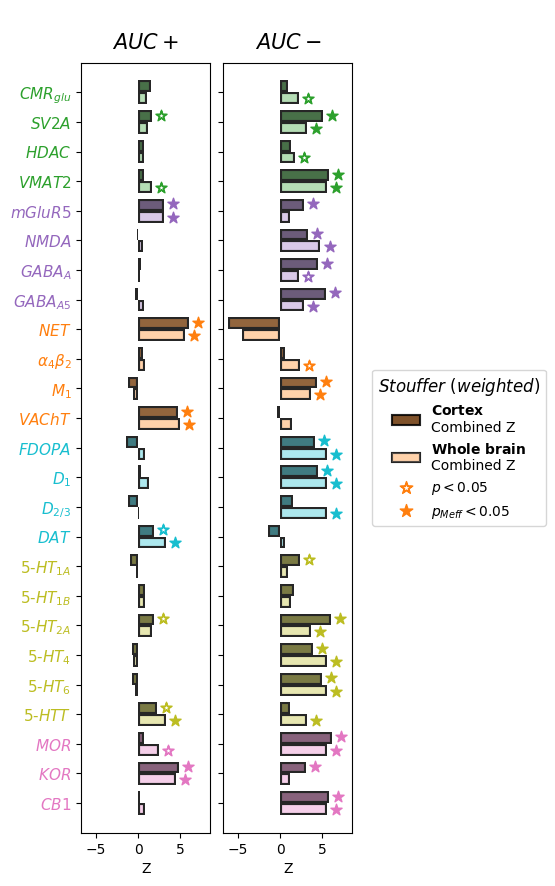

In [36]:
plot_metap(save_path=wd / "plots" / "replicability" / "metap_parc-Schaefer200.pdf")

### Correlation between AUCs

In [37]:
def plot_replic_heatmap(profile_corr_cx, profile_corr_wb, ax, dsets, cmaps=["rocket", "inferno"], 
                        title=None, icc_title=None, cbar=True):
    profile_corr_cx = profile_corr_cx.loc[dsets, dsets]
    tmp = pd.DataFrame(np.nan, index=dsets, columns=dsets)
    tmp.loc[profile_corr_wb.index, profile_corr_wb.columns] = profile_corr_wb
    profile_corr_wb = tmp
    
    # heatmap kwargs
    kwargs = {
        "ax": ax,
        "annot_kws": {"size": 9},
        "fmt": ".2f",
        "linewidths": 2,
        "linecolor": "w",
        "vmin": 0,
        "vmax": 1,
        "cbar": cbar 
    }
    
    # plot cortex as lower left triangle
    sn.heatmap(
        profile_corr_cx, 
        mask=np.triu(np.ones_like(profile_corr_cx), k=0),
        annot=True,
        cmap=cmaps[0], 
        cbar_ax=ax.inset_axes([1.2, 0, 0.07, 0.35]) if cbar else None,
        cbar_kws={"label": "Spearman's $\\rho$\n$\\bf{Cortex}$"},
        **kwargs
    )
    
    # plot whole-brain as upper right triangle
    
    # whole-brain not available
    cax = ax.inset_axes([1.2, 0.45, 0.07, 0.1]) if cbar else None
    sn.heatmap(
        np.ones_like(profile_corr_wb), 
        mask=np.tril(np.ones_like(profile_corr_cx, dtype=bool), k=0) | ~profile_corr_wb.isna().values,
        cmap=sn.color_palette(["0.8"]),
        cbar_ax=cax,
        cbar_kws={"label": "", "ticks": [0.5]},
        **kwargs
    )
    if cax is not None:
        cax.set_yticklabels(["Only cortex\navailable"])
        
    # actual whole-brain plot
    sn.heatmap(
        profile_corr_wb, 
        mask=np.tril(np.ones_like(profile_corr_wb), k=0),
        annot=True,
        cmap=cmaps[1], 
        cbar_ax=ax.inset_axes([1.2, 0.65, 0.07, 0.35]) if cbar else None,
        cbar_kws={"label": "Spearman's $\\rho$\n$\\bf{Whole\ brain}$"},
        **kwargs
    )
    
    # box marking ICC datasets
    n = len(dsets) - 1
    offset = 0.05
    extent = n - 2 * offset
    ax.add_patch(plt.Rectangle((offset, offset), extent, extent, fill=False, edgecolor="k", linewidth=2, zorder=20))
    ax.text(s=icc_title, x=n / 2, y=-0.3, ha="center", va="center", fontsize=12)
    
    # layout
    ax.set_yticks(ax.get_yticks(), labels=ax.get_yticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.set_xticks(ax.get_xticks(), labels=ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    if ax.get_subplotspec().is_first_col():
        pass
    else:
        ax.set_yticklabels([])
    ax.set_box_aspect(1)
    ax.set_title(f"$AUC\t{{{'+' if metric=='original' else '-'}}}$" if title is None else title, fontsize=15, pad=30)
    ax.set_xlabel("")
    ax.set_ylabel("")

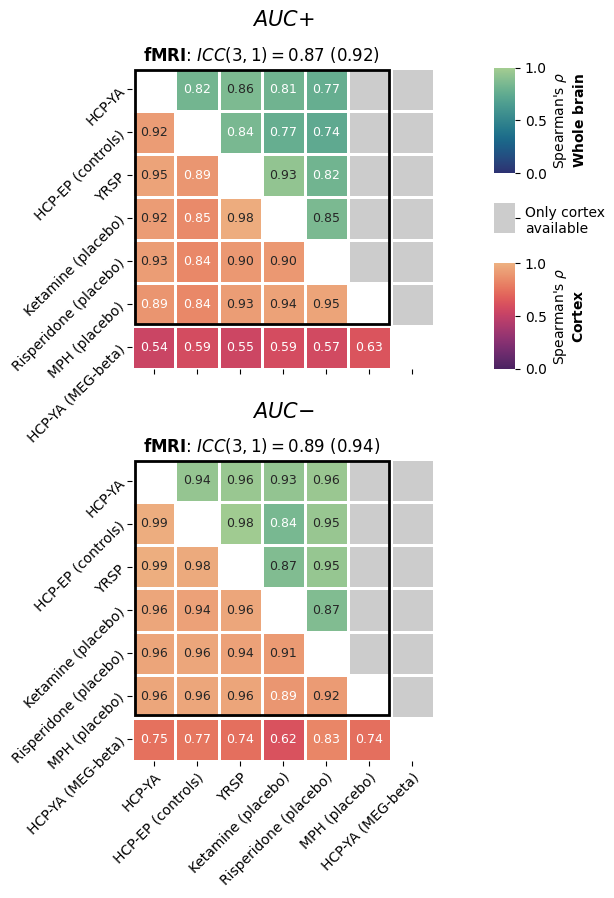

In [38]:
fig, axes = plt.subplots(2,1, figsize=(4.5, 9), gridspec_kw={"hspace": 0.3})

dsets = neofc_indivstats.index.get_level_values("dset").unique()
for i, metric in enumerate(["original", "inverted"]):
    plot_replic_heatmap(
        neofc_mri_replic_corr.loc[(parc_cx, metric, slice(None))].to_frame() \
            .pivot_table(index="cohort1", columns="cohort2", values="Spearman's rho"),
        neofc_mri_replic_corr.loc[(parc_wb, metric, slice(None))].to_frame() \
            .pivot_table(index="cohort1", columns="cohort2", values="Spearman's rho"),
        axes[i],
        dsets,
        cmaps=["flare_r", "crest_r"],
        icc_title=(
            r"$\bf{fMRI}$: " + f"$ICC(3,1) = {neofc_mri_replic_icc.loc[('Without MEG', parc_cx, metric), 'ICC']:.2f}$ "
            f"$({neofc_mri_replic_icc.loc[('Without MEG', parc_wb, metric), 'ICC']:.2f})$"
        ),
        cbar=i==0
    )  
    if i==0:
        axes[i].set_xticklabels([])
    
fig.savefig(wd / "plots" / "replicability" / "dsetcorr_parc-Schaefer200.pdf", bbox_inches="tight")